In [ ]:
# Install all required libraries
!pip install transformers torch torchvision pillow groq gradio fpdf2 openpyxl pandas deep-translator -q
print("✅ All libraries installed successfully!")
!pip install transformers torch torchvision pillow groq gradio fpdf2 openpyxl pandas deep-translator yagmail twilio gTTS -q
print("✅ All libraries installed!")
!pip install transformers torch torchvision pillow groq gradio fpdf2 openpyxl pandas deep-translator gTTS matplotlib -q
print("✅ All libraries installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.7/139.7 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 1.3 MB/s eta 0:00:00
✅ All libraries installed successfully!
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 385.7/385.7 kB 25.2 MB/s eta 0:00:00
✅ All libraries installed!
✅ All libraries installed!


In [ ]:
import torch
from PIL import Image
from transformers import BlipProcessor, BlipForConditionalGeneration
from groq import Groq
from google.colab import files
import IPython.display as display
import io

print("📁 Please upload ONE or MORE images (JPG or PNG)...")
print("   💡 Tip: Hold CTRL and click to select multiple files!\n")
uploaded = files.upload()

image_list = []
for filename, filedata in uploaded.items():
    img = Image.open(io.BytesIO(filedata)).convert("RGB")
    image_list.append({"filename": filename, "image": img})
    print(f"  ✅ Loaded: {filename}  ({img.size[0]}x{img.size[1]} px)")

print(f"\n📦 Total images uploaded: {len(image_list)}")

📁 Please upload ONE or MORE images (JPG or PNG)...
   💡 Tip: Hold CTRL and click to select multiple files!



Saving Screenshot 2026-03-18 092858.png to Screenshot 2026-03-18 092858.png
Saving Screenshot 2026-03-19 092730.png to Screenshot 2026-03-19 092730.png
Saving Screenshot 2026-03-19 162049.png to Screenshot 2026-03-19 162049.png
  ✅ Loaded: Screenshot 2026-03-18 092858.png  (596x329 px)
  ✅ Loaded: Screenshot 2026-03-19 092730.png  (633x376 px)
  ✅ Loaded: Screenshot 2026-03-19 162049.png  (595x406 px)

📦 Total images uploaded: 3


In [ ]:
# Load BLIP model and generate captions for all uploaded images
print("⏳ Loading BLIP model... (first run takes 1-2 minutes)\n")

try:
    processor = BlipProcessor.from_pretrained(
        "Salesforce/blip-image-captioning-base"
    )
    blip_model = BlipForConditionalGeneration.from_pretrained(
        "Salesforce/blip-image-captioning-base"
    )
    device = "cuda" if torch.cuda.is_available() else "cpu"
    blip_model = blip_model.to(device)
    print(f"✅ BLIP model loaded! Running on: {device.upper()}\n")

    for i, item in enumerate(image_list):
        inputs = processor(item["image"], return_tensors="pt").to(device)
        output = blip_model.generate(**inputs, max_new_tokens=60)
        caption = processor.decode(output[0], skip_special_tokens=True)
        image_list[i]["caption"] = caption
        print(f"  Image {i+1}: {item['filename']}")
        print(f"  Caption: {caption}\n")

    print(f"✅ All {len(image_list)} captions generated!")

except Exception as e:
    print(f"❌ Error: {e}")

⏳ Loading BLIP model... (first run takes 1-2 minutes)



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

✅ BLIP model loaded! Running on: CPU

  Image 1: Screenshot 2026-03-18 092858.png
  Caption: a car crashed into a bridge on the i - 95 in the bronx

  Image 2: Screenshot 2026-03-19 092730.png
  Caption: firefighters battle a house fire in the village of st paul, minnesota

  Image 3: Screenshot 2026-03-19 162049.png
  Caption: woman wearing a face mask in the city

✅ All 3 captions generated!


In [ ]:
# Analyze safety of ALL images using Groq API

# 🔑 PASTE YOUR GROQ API KEY BELOW
GROQ_API_KEY = ""   # <-- REPLACE THIS

# Validate key format
if not GROQ_API_KEY.startswith("gsk_") or len(GROQ_API_KEY) < 20:
    print("❌ API Key looks invalid!")
    print("   👉 Go to https://console.groq.com/keys and copy your real key.")
else:
    try:
        client = Groq(api_key=GROQ_API_KEY)
        print(f"✅ Groq connected! Analyzing {len(image_list)} images...\n")
        print("=" * 60)

        for i, item in enumerate(image_list):
            print(f"\n⏳ Analyzing Image {i+1}/{len(image_list)}: {item['filename']}")

            # Default fallback values
            image_list[i]["safety_label"] = "Unknown"
            image_list[i]["risk_score"]   = "N/A"
            image_list[i]["reason"]       = "Analysis not completed."

            try:
                # Build prompt for this image
                prompt = f"""Scene: {item['caption']}

Analyze the safety of this scene.
Give output in this exact format:

Safety: (Safe / Warning / Dangerous)
Risk Score: (a number between 0 and 100)
Reason: (clear explanation in simple English, 2-3 sentences)"""

                response = client.chat.completions.create(
                    model="llama-3.3-70b-versatile",
                    messages=[
                        {
                            "role": "system",
                            "content": (
                                "You are an expert scene safety analyst. "
                                "Analyze scenes and return ONLY structured output "
                                "with Safety label, Risk Score, and Reason. "
                                "Be concise and accurate."
                            )
                        },
                        {"role": "user", "content": prompt}
                    ],
                    temperature=0.3,
                    max_tokens=300
                )

                result_text = response.choices[0].message.content.strip()

                # Parse response fields
                for line in result_text.splitlines():
                    line = line.strip()
                    if line.lower().startswith("safety:"):
                        image_list[i]["safety_label"] = line.split(":", 1)[1].strip()
                    elif line.lower().startswith("risk score:"):
                        image_list[i]["risk_score"] = line.split(":", 1)[1].strip()
                    elif line.lower().startswith("reason:"):
                        image_list[i]["reason"] = line.split(":", 1)[1].strip()

                print(f"  ✅ Safety : {image_list[i]['safety_label']}")
                print(f"  ✅ Score  : {image_list[i]['risk_score']}/100")

            except Exception as inner_e:
                print(f"  ❌ Failed for {item['filename']}: {inner_e}")

        print(f"\n{'='*60}")
        print(f"✅ All {len(image_list)} images analyzed successfully!")

    except Exception as e:
        print(f"❌ Groq connection error: {e}")
        if "401" in str(e):
            print("   👉 Invalid API key — visit https://console.groq.com/keys")

✅ Groq connected! Analyzing 3 images...


⏳ Analyzing Image 1/3: Screenshot 2026-03-18 092858.png
  ✅ Safety : Dangerous
  ✅ Score  : 90/100

⏳ Analyzing Image 2/3: Screenshot 2026-03-19 092730.png
  ✅ Safety : Dangerous
  ✅ Score  : 90/100

⏳ Analyzing Image 3/3: Screenshot 2026-03-19 162049.png
  ✅ Safety : Safe
  ✅ Score  : 20/100

✅ All 3 images analyzed successfully!


   AI SCENE SAFETY ANALYZER — 3 IMAGE REPORT

────────────────────────────────────────────────────────────
  IMAGE 1     : Screenshot 2026-03-18 092858.png


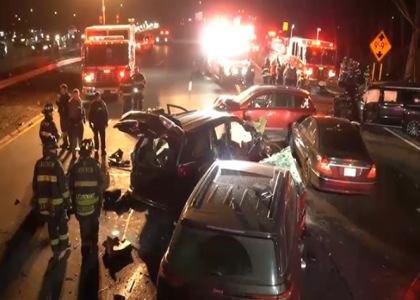

  CAPTION    : a car crashed into a bridge on the i - 95 in the bronx
  SAFETY     : 🔴 DANGEROUS
  RISK SCORE : [=========-] 90/100  🔴 HIGH RISK
  REASON     :
    The scene is dangerous because a car crash on a major highway like
    I-95 can lead to further accidents, injuries, or even explosions. The
    location near a bridge in the Bronx also poses a risk of structural
    damage or collapse. This situation requires immediate attention from
    emergency services to secure the area and prevent additional harm.
────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────
  IMAGE 2     : Screenshot 2026-03-19 092730.png


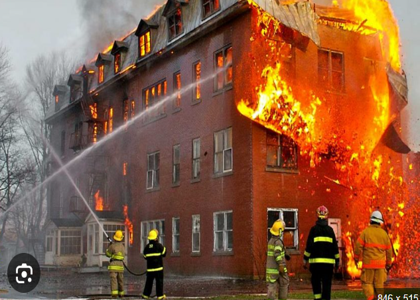

  CAPTION    : firefighters battle a house fire in the village of st paul, minnesota
  SAFETY     : 🔴 DANGEROUS
  RISK SCORE : [=========-] 90/100  🔴 HIGH RISK
  REASON     :
    The scene is dangerous because firefighters are battling a house fire,
    which poses a significant risk of injury from burns, falling debris,
    and explosions. The fire can also spread to nearby buildings, putting
    more people and properties at risk. The situation requires careful and
    immediate attention to ensure the safety of the firefighters and the
    surrounding community.
────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────
  IMAGE 3     : Screenshot 2026-03-19 162049.png


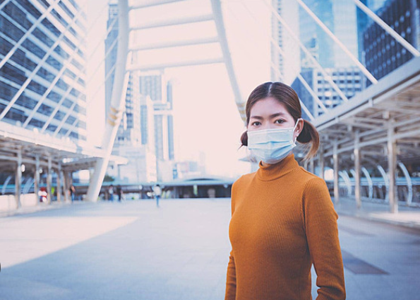

  CAPTION    : woman wearing a face mask in the city
  SAFETY     : 🟢 SAFE
  RISK SCORE : [==--------] 20/100  🟢 LOW RISK
  REASON     :
    The woman is wearing a face mask, which suggests she is taking
    precautions to protect herself from potential health risks such as air
    pollution or infectious diseases. The scene does not indicate any
    immediate threats or hazards. Overall, the situation appears to be
    low-risk and the woman's safety measures are appropriate.
────────────────────────────────────────────────────────────



   FINAL SUMMARY TABLE
  #    FILE                           SAFETY       SCORE
  ──── ────────────────────────────── ──────────── ──────────
  1    Screenshot 2026-03-18 092858   Dangerous    90/100
  2    Screenshot 2026-03-19 092730   Dangerous    90/100
  3    Screenshot 2026-03-19 162049   Safe         20/100

✅ Analysis Complete! 3 images processed.


In [ ]:
# Display results for ALL uploaded images
import textwrap

# ── Helper functions ───────────────────────────────────────

def get_safety_emoji(label):
    l = label.lower()
    if "dangerous" in l: return "🔴 DANGEROUS"
    elif "warning"  in l: return "🟡 WARNING"
    elif "safe"     in l: return "🟢 SAFE"
    else: return f"⚪ {label}"

def get_risk_bar(score_str):
    try:
        score  = int(''.join(filter(str.isdigit, score_str)))
        filled = int(score / 10)
        bar    = ("=" * filled) + ("-" * (10 - filled))
        return f"[{bar}] {score}/100"
    except:
        return str(score_str)

def get_risk_level(score_str):
    try:
        score = int(''.join(filter(str.isdigit, score_str)))
        if score >= 75:  return "🔴 HIGH RISK"
        elif score >= 40: return "🟡 MEDIUM RISK"
        else:             return "🟢 LOW RISK"
    except:
        return ""

def get_badge_color(label):
    l = label.lower()
    if "dangerous" in l: return "#FF3333", "🔴"
    elif "warning"  in l: return "#FFA500", "🟡"
    elif "safe"     in l: return "#00CC44", "🟢"
    else: return "#888888", "⚪"

# ── Summary header ─────────────────────────────────────────
print("=" * 60)
print(f"   AI SCENE SAFETY ANALYZER — {len(image_list)} IMAGE REPORT")
print("=" * 60)

# ── Loop through all images and show results ───────────────
html_cards = ""

for i, item in enumerate(image_list):
    label  = item.get("safety_label", "Unknown")
    score  = item.get("risk_score",   "N/A")
    reason = item.get("reason",       "N/A")
    cap    = item.get("caption",      "N/A")
    fname  = item.get("filename",     "Unknown")

    wrapped = textwrap.fill(reason, width=70)
    color, icon = get_badge_color(label)

    # ── Console output per image ───────────────────────────
    print(f"\n{'─'*60}")
    print(f"  IMAGE {i+1}     : {fname}")
    display.display(item["image"].resize((420, 300)))
    print(f"  CAPTION    : {cap}")
    print(f"  SAFETY     : {get_safety_emoji(label)}")
    print(f"  RISK SCORE : {get_risk_bar(score)}  {get_risk_level(score)}")
    print(f"  REASON     :")
    for line in wrapped.split('\n'):
        print(f"    {line}")
    print(f"{'─'*60}")

    # ── Build HTML card for this image ─────────────────────
    html_cards += f"""
    <div style="
        background:#1a1a2e;
        border-left: 5px solid {color};
        border-radius:12px;
        padding:20px 25px;
        margin-bottom:20px;
        font-family:monospace;
        color:#eee;
        max-width:650px;
    ">
      <h3 style="color:#00d4ff; margin-bottom:10px;">
        Image {i+1} — {fname}
      </h3>
      <p><b style="color:#aaa;">Caption:</b>
         <span style="color:#fff">{cap}</span></p>
      <p><b style="color:#aaa;">Safety:</b> &nbsp;
         <span style="color:{color}; font-weight:bold; font-size:16px">
           {icon} {label.upper()}
         </span>
      </p>
      <p><b style="color:#aaa;">Risk Score:</b>
         <span style="color:#fff; font-weight:bold;">
           {score}/100 — {get_risk_level(score)}
         </span>
      </p>
      <p><b style="color:#aaa;">Reason:</b><br>
         <span style="color:#ddd; line-height:1.8">{reason}</span>
      </p>
    </div>
    """

# ── Show all HTML cards together ───────────────────────────
display.display(display.HTML(f"""
<div>
  <h2 style="font-family:monospace; color:#00d4ff; margin-bottom:20px;">
    📊 AI Safety Analysis — All {len(image_list)} Images
  </h2>
  {html_cards}
</div>
"""))

# ── Final summary table ────────────────────────────────────
print("\n" + "=" * 60)
print("   FINAL SUMMARY TABLE")
print("=" * 60)
print(f"  {'#':<4} {'FILE':<30} {'SAFETY':<12} {'SCORE'}")
print(f"  {'─'*4} {'─'*30} {'─'*12} {'─'*10}")
for i, item in enumerate(image_list):
    lbl   = item.get("safety_label", "Unknown")
    sc    = item.get("risk_score",   "N/A")
    fname = item.get("filename", "")[:28]
    print(f"  {i+1:<4} {fname:<30} {lbl:<12} {sc}/100")

print("=" * 60)
print(f"\n✅ Analysis Complete! {len(image_list)} images processed.")

In [ ]:
# ============================================================
# CELL 6 — BEAUTIFUL UI
# ✅ FIXED voice output (auto-play + player both)
# ✅ Removed WhatsApp & Email tabs
# ✅ NEW: Safety score chart (bar + pie)
# ✅ NEW: Live progress status per image
# ✅ NEW: Safety heatmap overlay on image
# ✅ PDF + CSV + Excel export
# ✅ Multi-language, Compare, AI Summary
# ============================================================

import gradio as gr
import torch
from PIL import Image, ImageDraw, ImageFont, ImageFilter
import numpy as np
from groq import Groq
import json, datetime, os, io, base64
from fpdf import FPDF
import pandas as pd
from deep_translator import GoogleTranslator
from gtts import gTTS
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

GROQ_API_KEY = ""  # <-- REPLACE

LANGUAGES = {
    "🌐 English":  "en",
    "🇮🇳 Tamil":   "ta",
    "🇮🇳 Hindi":   "hi",
    "🇪🇸 Spanish": "es",
    "🇫🇷 French":  "fr",
    "🇩🇪 German":  "de",
    "🇦🇪 Arabic":  "ar",
}

CSS = """
* { font-family:'Segoe UI',system-ui,sans-serif !important; box-sizing:border-box !important; }
.gradio-container { background:#f0f4ff !important; max-width:1300px !important; }
.tab-nav { background:#fff !important; border-radius:16px !important; padding:6px !important;
           box-shadow:0 2px 12px rgba(0,0,0,0.08) !important; margin-bottom:20px !important; border:none !important; }
.tab-nav button { color:#666 !important; font-weight:600 !important; font-size:13px !important;
                  border-radius:12px !important; padding:10px 18px !important; border:none !important;
                  background:transparent !important; transition:all 0.2s !important; }
.tab-nav button.selected { color:#fff !important;
                           background:linear-gradient(135deg,#667eea,#764ba2) !important;
                           box-shadow:0 4px 14px rgba(102,126,234,0.4) !important; }
.tab-nav button:hover:not(.selected) { background:#f0f4ff !important; color:#667eea !important; }
.gr-button-primary,button.primary { background:linear-gradient(135deg,#667eea,#764ba2) !important;
  color:#fff !important; font-weight:700 !important; font-size:14px !important;
  border-radius:14px !important; border:none !important;
  box-shadow:0 4px 18px rgba(102,126,234,0.35) !important;
  padding:12px 24px !important; transition:all 0.25s !important; }
.gr-button-primary:hover,button.primary:hover { transform:translateY(-2px) !important;
  box-shadow:0 8px 24px rgba(102,126,234,0.45) !important; }
.gr-button-secondary,button.secondary { background:#fff !important; color:#667eea !important;
  border:2px solid #667eea !important; border-radius:12px !important;
  font-weight:600 !important; transition:all 0.2s !important; }
.gr-button-secondary:hover,button.secondary:hover { background:#f0f4ff !important; }
input,textarea,select { background:#fff !important; border:2px solid #e8ecf0 !important;
  border-radius:12px !important; color:#333 !important; font-size:14px !important; }
input:focus,textarea:focus { border-color:#667eea !important;
  box-shadow:0 0 0 4px rgba(102,126,234,0.12) !important; }
label span,.label-wrap span { color:#555 !important; font-size:12px !important;
  font-weight:700 !important; letter-spacing:0.8px !important; text-transform:uppercase !important; }
.info { color:#888 !important; font-size:12px !important; }
.prose h3 { color:#333 !important; font-size:18px !important; font-weight:800 !important; }
.prose p { color:#666 !important; }
"""

# ══════════════════════════════════════════════════════════
# HELPERS
# ══════════════════════════════════════════════════════════

def get_color(label):
    l = label.lower()
    if "dangerous" in l: return "#FF4757","🔴","#FF47571A"
    elif "warning"  in l: return "#FF6B35","🟡","#FF6B351A"
    elif "safe"     in l: return "#20BF6B","🟢","#20BF6B1A"
    else:                 return "#778CA3","⚪","#778CA31A"

def get_risk_level(score):
    if score >= 75:   return "HIGH RISK"
    elif score >= 40: return "MEDIUM RISK"
    else:             return "LOW RISK"

def get_risk_color(score):
    if score >= 75:   return "#FF4757"
    elif score >= 40: return "#FF6B35"
    else:             return "#20BF6B"

def get_confidence(score):
    if score >= 85:   return "Very High","#FF4757"
    elif score >= 65: return "High","#FF6B35"
    elif score >= 45: return "Medium","#F7B731"
    elif score >= 25: return "Low","#45AAF2"
    else:             return "Very Low","#20BF6B"

def get_tips_text(label):
    l = label.lower()
    if "dangerous" in l:
        return [
            "Evacuate the area immediately",
            "Call emergency services 911",
            "Set up a safety perimeter",
            "Document the scene for reports",
            "Check for injuries and get medical help"
        ]
    elif "warning" in l:
        return [
            "Proceed with extreme caution",
            "Monitor the situation closely",
            "Alert relevant authorities",
            "Ensure proper lighting and visibility",
            "Wear protective gear if entering"
        ]
    else:
        return [
            "Scene appears safe to proceed",
            "Stay alert and situationally aware",
            "Keep emergency contacts ready",
            "Re-analyze if conditions change",
            "Log this assessment for records"
        ]

def get_tips_display(label):
    l = label.lower()
    if "dangerous" in l:
        return [
            "Evacuate the area immediately",
            "Call emergency services (911)",
            "Set up a safety perimeter",
            "Document scene for official reports",
            "Check for injuries — seek medical help"
        ]
    elif "warning" in l:
        return [
            "Proceed with extreme caution",
            "Monitor the situation closely",
            "Alert relevant authorities",
            "Ensure proper lighting and visibility",
            "Wear protective gear if entering"
        ]
    else:
        return [
            "Scene appears safe to proceed",
            "Stay alert and aware",
            "Keep emergency contacts ready",
            "Re-analyze if conditions change",
            "Log this assessment for records"
        ]

def translate_text(text, lang_code):
    if lang_code == "en" or not text:
        return text
    try:
        return GoogleTranslator(source="en",target=lang_code).translate(str(text))
    except:
        return text

def safe_str(text):
    if not text: return ""
    try:
        return str(text).encode("latin-1",errors="replace").decode("latin-1")
    except:
        return ''.join(c if ord(c)<128 else '?' for c in str(text))

def _err_html(msg):
    return f"""<div style="background:#fff5f5;border:2px solid #FF4757;
        border-radius:16px;padding:32px;text-align:center;font-family:'Segoe UI',sans-serif;">
      <div style="font-size:52px;margin-bottom:12px">&#9888;</div>
      <p style="color:#FF4757;font-size:16px;font-weight:600;margin:0">{msg}</p></div>"""

# ══════════════════════════════════════════════════════════
# CORE ANALYSIS
# ══════════════════════════════════════════════════════════

def analyze_one(img_array, api_key):
    img     = Image.fromarray(img_array).convert("RGB")
    inputs  = processor(img, return_tensors="pt").to(device)
    out     = blip_model.generate(**inputs, max_new_tokens=60)
    caption = processor.decode(out[0], skip_special_tokens=True)

    client = Groq(api_key=api_key.strip())
    prompt = f"""Scene: {caption}
Analyze the safety of this scene.
Give output in this exact format:
Safety: (Safe / Warning / Dangerous)
Risk Score: (a number between 0 and 100)
Reason: (clear explanation in simple English, 2-3 sentences)"""

    resp = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {"role":"system","content":"You are an expert scene safety analyst. Return ONLY structured output."},
            {"role":"user","content":prompt}
        ],
        temperature=0.3, max_tokens=300
    )

    text         = resp.choices[0].message.content.strip()
    safety_label = "Unknown"
    risk_score   = 0
    reason       = "Could not parse."

    for line in text.splitlines():
        line = line.strip()
        if line.lower().startswith("safety:"):
            safety_label = line.split(":",1)[1].strip()
        elif line.lower().startswith("risk score:"):
            try:
                risk_score = int(''.join(filter(str.isdigit, line.split(":",1)[1])))
            except:
                risk_score = 0
        elif line.lower().startswith("reason:"):
            reason = line.split(":",1)[1].strip()

    return caption, safety_label, risk_score, reason

# ══════════════════════════════════════════════════════════
# ✅ FEATURE 1: FIXED VOICE OUTPUT
# ══════════════════════════════════════════════════════════

def generate_voice(history_json, lang_choice):
    """
    ✅ FIXED voice output.
    Returns (audio_path, status_message).
    Audio file saved to /tmp/voice_report.mp3
    """
    try:
        h = json.loads(history_json) if history_json else []
        if not h:
            return None, "⚠️ No analysis data! Analyze images first then click Generate Voice Report."

        lang_code = LANGUAGES.get(lang_choice, "en")
        total     = len(h)
        dangerous = sum(1 for r in h if "dangerous" in r.get("safety_label","").lower())
        warning   = sum(1 for r in h if "warning"   in r.get("safety_label","").lower())
        safe_ct   = total - dangerous - warning

        # Build natural speech text
        speech_parts = [
            "AI Scene Safety Analysis Report.",
            f"Total images analyzed: {total}.",
            f"Dangerous scenes: {dangerous}.",
            f"Warning scenes: {warning}.",
            f"Safe scenes: {safe_ct}.",
        ]

        if dangerous > 0:
            speech_parts.append(
                "Alert! Dangerous scenes were detected. "
                "Please evacuate immediately and call emergency services."
            )
        elif warning > 0:
            speech_parts.append(
                "Warning scenes detected. Please proceed with caution."
            )
        else:
            speech_parts.append("All scenes are safe.")

        # Add individual image summaries (max 3)
        for i, r in enumerate(h[:3]):
            lbl = r.get("safety_label", "Unknown")
            sc  = r.get("risk_score", 0)
            rsn = r.get("reason", "")
            speech_parts.append(
                f"Image {i+1}. Safety: {lbl}. "
                f"Risk score: {sc} out of 100. "
                f"{rsn}"
            )

        speech_parts.append("End of safety report.")
        speech = " ".join(speech_parts)

        # Translate if needed
        if lang_code != "en":
            try:
                speech = GoogleTranslator(
                    source="en", target=lang_code
                ).translate(speech)
                print(f"Voice translated to: {lang_code}")
            except Exception as te:
                print(f"Translation failed: {te}, using English")
                lang_code = "en"

        # Generate audio file
        print(f"Generating voice for {len(speech)} chars in lang={lang_code}")
        tts  = gTTS(text=speech, lang=lang_code, slow=False)
        path = "/tmp/voice_report.mp3"
        tts.save(path)

        if os.path.exists(path):
            size = os.path.getsize(path)
            print(f"✅ Voice file saved: {path} ({size} bytes)")
            return path, f"✅ Voice report ready! ({size//1024+1} KB) — Press play below"
        else:
            return None, "❌ Voice file was not saved"

    except Exception as e:
        print(f"Voice error: {type(e).__name__}: {e}")
        import traceback
        traceback.print_exc()
        return None, f"❌ Voice error: {str(e)[:120]}"

# ══════════════════════════════════════════════════════════
# ✅ FEATURE 2: SAFETY SCORE CHART
# ══════════════════════════════════════════════════════════

def generate_chart(history_json):
    """Generate bar + pie chart of safety results"""
    try:
        h = json.loads(history_json) if history_json else []
        if not h:
            return None, "⚠️ Analyze images first!"

        dangerous = sum(1 for r in h if "dangerous" in r.get("safety_label","").lower())
        warning   = sum(1 for r in h if "warning"   in r.get("safety_label","").lower())
        safe_ct   = len(h) - dangerous - warning

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        fig.patch.set_facecolor("#f0f4ff")

        # ── Bar chart ────────────────────────────────────
        ax1 = axes[0]
        ax1.set_facecolor("#ffffff")
        categories = ["Dangerous", "Warning", "Safe"]
        values     = [dangerous, warning, safe_ct]
        colors     = ["#FF4757", "#FF6B35", "#20BF6B"]

        bars = ax1.bar(
            categories, values,
            color=colors, width=0.5,
            edgecolor="white", linewidth=2,
            zorder=3
        )
        ax1.set_title(
            "Safety Analysis — Bar Chart",
            fontsize=15, fontweight="bold",
            color="#333", pad=15
        )
        ax1.set_ylabel("Number of Scenes", fontsize=12, color="#555")
        ax1.set_ylim(0, max(values) + 1.5)
        ax1.grid(axis="y", alpha=0.3, zorder=0)
        ax1.spines["top"].set_visible(False)
        ax1.spines["right"].set_visible(False)
        ax1.tick_params(colors="#555")

        # Value labels on bars
        for bar, val in zip(bars, values):
            if val > 0:
                ax1.text(
                    bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.1,
                    str(val),
                    ha="center", va="bottom",
                    fontsize=14, fontweight="bold",
                    color="#333"
                )

        # ── Pie chart ────────────────────────────────────
        ax2 = axes[1]
        ax2.set_facecolor("#ffffff")

        pie_values  = [v for v in [dangerous, warning, safe_ct] if v > 0]
        pie_labels  = [l for l, v in zip(categories, [dangerous, warning, safe_ct]) if v > 0]
        pie_colors  = [c for c, v in zip(colors, [dangerous, warning, safe_ct]) if v > 0]
        pie_explode = [0.05] * len(pie_values)

        if pie_values:
            wedges, texts, autotexts = ax2.pie(
                pie_values,
                labels=pie_labels,
                colors=pie_colors,
                autopct="%1.0f%%",
                explode=pie_explode,
                startangle=90,
                textprops={"fontsize":12, "color":"#333"},
                wedgeprops={"edgecolor":"white","linewidth":2}
            )
            for at in autotexts:
                at.set_fontsize(13)
                at.set_fontweight("bold")
                at.set_color("white")
        else:
            ax2.text(0.5, 0.5, "No data", ha="center", va="center",
                     fontsize=14, color="#888")

        ax2.set_title(
            "Safety Distribution — Pie Chart",
            fontsize=15, fontweight="bold",
            color="#333", pad=15
        )

        plt.tight_layout(pad=3)

        # Save chart
        chart_path = "/tmp/safety_chart.png"
        plt.savefig(
            chart_path, dpi=150,
            bbox_inches="tight",
            facecolor="#f0f4ff"
        )
        plt.close(fig)

        if os.path.exists(chart_path):
            size = os.path.getsize(chart_path)
            print(f"✅ Chart saved: {size} bytes")
            return chart_path, f"✅ Chart ready — {len(h)} images analyzed"
        return None, "❌ Chart generation failed"

    except Exception as e:
        print(f"Chart error: {e}")
        import traceback
        traceback.print_exc()
        return None, f"❌ Chart error: {str(e)[:100]}"

# ══════════════════════════════════════════════════════════
# ✅ FEATURE 3: SAFETY HEATMAP OVERLAY
# ══════════════════════════════════════════════════════════

def generate_heatmap(img_input, score, label):
    """
    Create a safety heatmap overlay on the image.
    Red = dangerous areas, green = safe areas.
    """
    try:
        if img_input is None:
            return None

        img  = Image.fromarray(img_input).convert("RGBA")
        W, H = img.size

        # Create heatmap layer
        heat = Image.new("RGBA", (W, H), (0, 0, 0, 0))
        draw = ImageDraw.Draw(heat)

        lbl_l = label.lower()

        if "dangerous" in lbl_l:
            # Red vignette overlay
            for i in range(30):
                alpha = int(120 * (i / 30))
                r     = max(W, H) - i * (max(W, H) // 30)
                draw.ellipse(
                    [W//2 - r, H//2 - r, W//2 + r, H//2 + r],
                    outline=(255, 71, 87, alpha)
                )
            # Red border flash
            for t in range(12):
                draw.rectangle(
                    [t, t, W-t-1, H-t-1],
                    outline=(255, 71, 87, 200 - t*15)
                )
        elif "warning" in lbl_l:
            # Orange vignette
            for i in range(25):
                alpha = int(100 * (i / 25))
                r     = max(W, H) - i * (max(W, H) // 25)
                draw.ellipse(
                    [W//2 - r, H//2 - r, W//2 + r, H//2 + r],
                    outline=(255, 107, 53, alpha)
                )
            for t in range(10):
                draw.rectangle(
                    [t, t, W-t-1, H-t-1],
                    outline=(255, 107, 53, 180 - t*15)
                )
        else:
            # Green safe border
            for t in range(10):
                draw.rectangle(
                    [t, t, W-t-1, H-t-1],
                    outline=(32, 191, 107, 200 - t*18)
                )

        # Blend overlay onto image
        result = Image.alpha_composite(img, heat).convert("RGB")

        # Add text label on image
        draw2 = ImageDraw.Draw(result)
        try:
            font_lg = ImageFont.truetype(
                "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 28
            )
            font_sm = ImageFont.truetype(
                "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 18
            )
        except:
            font_lg = ImageFont.load_default()
            font_sm = font_lg

        # Background pill for label text
        lbl_text  = f"  {label.upper()}  "
        rl_text   = f"  RISK SCORE: {score}/100  "

        if "dangerous" in lbl_l:   bg_color = (255, 71, 87)
        elif "warning"  in lbl_l:  bg_color = (255, 107, 53)
        else:                       bg_color = (32, 191, 107)

        # Top label pill
        draw2.rectangle([10, 10, 280, 50], fill=bg_color)
        draw2.text((16, 14), lbl_text, fill=(255,255,255), font=font_lg)

        # Bottom score pill
        draw2.rectangle([10, H-50, 260, H-10], fill=(0, 0, 0, 160))
        draw2.text((16, H-44), rl_text, fill=(255,255,255), font=font_sm)

        # Save heatmap
        hmap_path = "/tmp/heatmap.png"
        result.save(hmap_path)
        return hmap_path

    except Exception as e:
        print(f"Heatmap error: {e}")
        return None

# ══════════════════════════════════════════════════════════
# AI SUMMARY
# ══════════════════════════════════════════════════════════

def generate_ai_summary(history_json, api_key):
    try:
        h = json.loads(history_json) if history_json else []
        if not h:
            return "Analyze images first!"
        if not api_key.strip().startswith("gsk_"):
            return "Invalid API Key!"

        dangerous = sum(1 for r in h if "dangerous" in r.get("safety_label","").lower())
        warning   = sum(1 for r in h if "warning"   in r.get("safety_label","").lower())
        safe_ct   = len(h) - dangerous - warning

        data_text = f"Total images: {len(h)}\n"
        for i,r in enumerate(h):
            data_text += (
                f"\nScene {i+1}: {r.get('filename','')}\n"
                f"  Safety: {r.get('safety_label','')}  "
                f"Score: {r.get('risk_score',0)}/100\n"
                f"  Reason: {r.get('reason','')}\n"
            )

        client = Groq(api_key=api_key.strip())
        resp   = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role":"system",
                 "content":"You are a certified safety officer writing executive-level safety reports."},
                {"role":"user","content":f"""
Write a professional executive safety report:
{data_text}
Stats: Total={len(h)} Dangerous={dangerous} Warning={warning} Safe={safe_ct}
Overall Risk: {"HIGH" if dangerous>0 else "MEDIUM" if warning>0 else "LOW"}

Include:
1. EXECUTIVE SUMMARY (2 paragraphs)
2. KEY FINDINGS (4-5 bullet points)
3. RISK ASSESSMENT (1 paragraph)
4. RECOMMENDATIONS (4-5 actions)
5. CONCLUSION (1 paragraph)
"""}
            ],
            temperature=0.3, max_tokens=1000
        )
        return resp.choices[0].message.content.strip()
    except Exception as e:
        return f"Error: {str(e)[:150]}"

# ══════════════════════════════════════════════════════════
# COMPARE IMAGES
# ══════════════════════════════════════════════════════════

def compare_images(img1, img2, api_key):
    if img1 is None or img2 is None:
        return _err_html("Please upload BOTH images!"), None
    if not api_key.strip().startswith("gsk_"):
        return _err_html("Invalid API Key!"), None
    try:
        cap1,lbl1,sc1,rsn1 = analyze_one(img1, api_key)
        cap2,lbl2,sc2,rsn2 = analyze_one(img2, api_key)
        col1,ic1,bg1 = get_color(lbl1)
        col2,ic2,bg2 = get_color(lbl2)
        rl1 = get_risk_level(sc1)
        rl2 = get_risk_level(sc2)

        pil1   = Image.fromarray(img1).convert("RGB").resize((460,345))
        pil2   = Image.fromarray(img2).convert("RGB").resize((460,345))
        canvas = Image.new("RGB",(940,440),(248,250,255))
        canvas.paste(pil1,(0,55)); canvas.paste(pil2,(480,55))
        draw   = ImageDraw.Draw(canvas)

        def hex2rgb(h):
            h=h.lstrip("#"); return tuple(int(h[i:i+2],16) for i in (0,2,4))

        draw.rectangle([0,0,460,50],   fill=hex2rgb(col1))
        draw.rectangle([480,0,940,50], fill=hex2rgb(col2))
        try:
            font = ImageFont.truetype(
                "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",16
            )
        except:
            font = ImageFont.load_default()

        draw.text((10,16),  f"SCENE A: {lbl1.upper()} - {sc1}/100", fill=(255,255,255), font=font)
        draw.text((490,16), f"SCENE B: {lbl2.upper()} - {sc2}/100", fill=(255,255,255), font=font)
        draw.rectangle([0,400,940,440], fill=(230,235,255))
        bw1=int((sc1/100)*450); bw2=int((sc2/100)*450)
        draw.rectangle([5,410,5+bw1,432],   fill=hex2rgb(col1))
        draw.rectangle([485,410,485+bw2,432], fill=hex2rgb(col2))
        comp_path="/tmp/comparison.png"; canvas.save(comp_path)

        diff=abs(sc1-sc2)
        if sc1>sc2:   v_txt=f"Scene A is MORE dangerous (+{diff} pts)"; v_col=col1
        elif sc2>sc1: v_txt=f"Scene B is MORE dangerous (+{diff} pts)"; v_col=col2
        else:         v_txt="Both scenes have equal risk"; v_col="#FF6B35"

        html=f"""<div style="background:#fff;border-radius:22px;padding:26px;
            font-family:'Segoe UI',sans-serif;box-shadow:0 8px 36px rgba(0,0,0,0.10);">
          <div style="text-align:center;margin-bottom:20px;">
            <h2 style="color:#333;margin:0;font-size:22px;font-weight:800">
              Side-by-Side Comparison</h2>
            <p style="color:#888;margin:4px 0 0 0;font-size:13px">
              {datetime.datetime.now().strftime('%B %d, %Y %H:%M')}</p>
          </div>
          <div style="background:linear-gradient(135deg,{v_col}18,{v_col}08);
              border:2px solid {v_col}55;border-radius:14px;
              padding:13px;text-align:center;margin-bottom:20px;">
            <p style="color:{v_col};margin:0;font-size:16px;font-weight:800">
              {v_txt}</p>
          </div>
          <div style="display:grid;grid-template-columns:1fr 1fr;gap:16px;">
            <div style="background:linear-gradient(135deg,{bg1},{col1}0A);
                border:2px solid {col1}33;border-radius:18px;padding:20px;">
              <div style="display:flex;justify-content:space-between;
                  align-items:center;margin-bottom:12px;">
                <h3 style="color:#333;margin:0;font-size:16px;font-weight:800">Scene A</h3>
                <span style="background:{col1};color:#fff;padding:4px 14px;
                    border-radius:20px;font-size:12px;font-weight:800">
                  {ic1} {lbl1.upper()}</span>
              </div>
              <p style="color:#666;font-size:11px;margin:0 0 4px 0;
                  font-weight:700;text-transform:uppercase">Caption</p>
              <p style="color:#444;font-style:italic;font-size:13px;
                  margin:0 0 14px 0">"{cap1}"</p>
              <div style="text-align:center;margin-bottom:10px;">
                <span style="font-size:48px;font-weight:900;color:{col1}">{sc1}</span>
                <span style="font-size:16px;color:#aaa">/100</span>
                <p style="color:{col1};font-weight:800;margin:4px 0 0 0">{rl1}</p>
              </div>
              <div style="background:rgba(0,0,0,0.06);border-radius:20px;
                  height:10px;overflow:hidden;margin-bottom:12px;">
                <div style="background:{col1};width:{sc1}%;height:100%;border-radius:20px;"></div>
              </div>
              <p style="color:#555;font-size:13px;line-height:1.7;margin:0">{rsn1}</p>
            </div>
            <div style="background:linear-gradient(135deg,{bg2},{col2}0A);
                border:2px solid {col2}33;border-radius:18px;padding:20px;">
              <div style="display:flex;justify-content:space-between;
                  align-items:center;margin-bottom:12px;">
                <h3 style="color:#333;margin:0;font-size:16px;font-weight:800">Scene B</h3>
                <span style="background:{col2};color:#fff;padding:4px 14px;
                    border-radius:20px;font-size:12px;font-weight:800">
                  {ic2} {lbl2.upper()}</span>
              </div>
              <p style="color:#666;font-size:11px;margin:0 0 4px 0;
                  font-weight:700;text-transform:uppercase">Caption</p>
              <p style="color:#444;font-style:italic;font-size:13px;
                  margin:0 0 14px 0">"{cap2}"</p>
              <div style="text-align:center;margin-bottom:10px;">
                <span style="font-size:48px;font-weight:900;color:{col2}">{sc2}</span>
                <span style="font-size:16px;color:#aaa">/100</span>
                <p style="color:{col2};font-weight:800;margin:4px 0 0 0">{rl2}</p>
              </div>
              <div style="background:rgba(0,0,0,0.06);border-radius:20px;
                  height:10px;overflow:hidden;margin-bottom:12px;">
                <div style="background:{col2};width:{sc2}%;height:100%;border-radius:20px;"></div>
              </div>
              <p style="color:#555;font-size:13px;line-height:1.7;margin:0">{rsn2}</p>
            </div>
          </div>
        </div>"""
        return html, comp_path
    except Exception as e:
        return _err_html(f"Error: {str(e)[:100]}"), None

# ══════════════════════════════════════════════════════════
# EXPORTS
# ══════════════════════════════════════════════════════════

def build_pdf(history):
    try:
        if not history: return None
        pdf = FPDF()
        pdf.set_auto_page_break(auto=True, margin=15)
        pdf.add_page()
        pdf.set_font("Helvetica","B",22)
        pdf.set_text_color(70,90,210)
        pdf.cell(0,14,"AI Scene Safety Analyzer",ln=True,align="C")
        pdf.set_font("Helvetica","",10)
        pdf.set_text_color(130,130,130)
        pdf.cell(0,7,f"Generated: {datetime.datetime.now():%Y-%m-%d %H:%M}  |  Total: {len(history)}",ln=True,align="C")
        pdf.ln(8)
        for i,item in enumerate(history):
            lbl   = safe_str(item.get("safety_label","Unknown"))
            sc    = item.get("risk_score",0)
            cap   = safe_str(item.get("caption","N/A"))
            rsn   = safe_str(item.get("reason","N/A"))
            fname = safe_str(item.get("filename",f"Image_{i+1}"))
            pdf.set_font("Helvetica","B",13)
            pdf.set_text_color(50,70,180)
            pdf.cell(0,10,f"Image {i+1}: {fname[:60]}",ln=True)
            lbl_l = lbl.lower()
            pdf.set_font("Helvetica","B",11)
            if "dangerous" in lbl_l:   pdf.set_text_color(210,40,40)
            elif "warning"  in lbl_l:  pdf.set_text_color(210,110,20)
            else:                       pdf.set_text_color(15,150,70)
            pdf.cell(0,8,f"Safety: {lbl.upper()}  Score: {sc}/100  {get_risk_level(sc)}",ln=True)
            pdf.set_text_color(40,40,40)
            pdf.set_font("Helvetica","",10)
            pdf.cell(0,7,f"Caption: {cap[:120]}",ln=True)
            pdf.set_font("Helvetica","I",10)
            pdf.multi_cell(0,7,f"Reason: {rsn[:300]}")
            pdf.ln(2)
            tips = get_tips_text(lbl)
            pdf.set_font("Helvetica","B",10)
            pdf.set_text_color(60,60,60)
            pdf.cell(0,7,"Safety Actions:",ln=True)
            pdf.set_font("Helvetica","",10)
            for t in tips:
                pdf.cell(0,6,f"  - {t}",ln=True)
            pdf.ln(5)
            pdf.set_draw_color(200,205,230)
            pdf.line(10,pdf.get_y(),200,pdf.get_y())
            pdf.ln(6)
        path="/tmp/safety_report.pdf"
        pdf.output(path)
        return path if os.path.exists(path) else None
    except Exception as e:
        print(f"PDF error: {e}"); return None

def gen_pdf(hj):
    try:
        if not hj or hj.strip() in ("","[]"):
            return gr.update(value=None,visible=True,label="No data yet!")
        h = json.loads(hj)
        p = build_pdf(h)
        if p and os.path.exists(p):
            return gr.update(value=p,visible=True,label=f"PDF Ready ({len(h)} images)")
        return gr.update(value=None,visible=True,label="PDF failed")
    except Exception as e:
        print(f"gen_pdf error: {e}")
        return gr.update(value=None,visible=False)

def build_csv(history):
    try:
        if not history: return None
        rows = [{"Filename":r.get("filename",""),"Timestamp":r.get("timestamp",""),
                 "Caption":r.get("caption",""),"Safety":r.get("safety_label",""),
                 "Risk Score":r.get("risk_score",0),"Risk Level":get_risk_level(r.get("risk_score",0)),
                 "Confidence":get_confidence(r.get("risk_score",0))[0],"Reason":r.get("reason","")}
                for r in history]
        df=pd.DataFrame(rows); path="/tmp/safety_report.csv"
        df.to_csv(path,index=False,encoding="utf-8-sig")
        return path
    except Exception as e:
        print(f"CSV error: {e}"); return None

def gen_csv(hj):
    try:
        if not hj or hj.strip() in ("","[]"):
            return gr.update(value=None,visible=False)
        h=json.loads(hj); p=build_csv(h)
        return gr.update(value=p,visible=True,label=f"CSV Ready ({len(h)} records)") if p and os.path.exists(p) else gr.update(value=None,visible=False)
    except Exception as e:
        print(f"gen_csv error: {e}"); return gr.update(value=None,visible=False)

def build_excel(history):
    try:
        if not history: return None
        rows = [{"Filename":r.get("filename",""),"Timestamp":r.get("timestamp",""),
                 "Caption":r.get("caption",""),"Safety":r.get("safety_label",""),
                 "Risk Score":r.get("risk_score",0),"Risk Level":get_risk_level(r.get("risk_score",0)),
                 "Confidence":get_confidence(r.get("risk_score",0))[0],"Reason":r.get("reason","")}
                for r in history]
        df=pd.DataFrame(rows); path="/tmp/safety_report.xlsx"
        with pd.ExcelWriter(path,engine="openpyxl") as w:
            df.to_excel(w,sheet_name="Safety Analysis",index=False)
            ws=w.sheets["Safety Analysis"]
            for col in ws.columns:
                ws.column_dimensions[col[0].column_letter].width = min(
                    max(len(str(c.value or "")) for c in col)+4,55)
        return path
    except Exception as e:
        print(f"Excel error: {e}"); return None

def gen_excel(hj):
    try:
        if not hj or hj.strip() in ("","[]"):
            return gr.update(value=None,visible=False)
        h=json.loads(hj); p=build_excel(h)
        return gr.update(value=p,visible=True,label=f"Excel Ready ({len(h)} records)") if p and os.path.exists(p) else gr.update(value=None,visible=False)
    except Exception as e:
        print(f"gen_excel error: {e}"); return gr.update(value=None,visible=False)

# ══════════════════════════════════════════════════════════
# MAIN ANALYSIS WITH LIVE PROGRESS
# ══════════════════════════════════════════════════════════

def analyze_all(file_list, api_key, theme, lang_choice, history_json):
    no_vis = [gr.update(visible=False)] * 6

    if not api_key.strip().startswith("gsk_") or len(api_key.strip()) < 20:
        return [_err_html("Invalid API Key!"), history_json] + no_vis
    if not file_list or len(file_list) == 0:
        return [_err_html("No images uploaded!"), history_json] + no_vis

    lang_code = LANGUAGES.get(lang_choice,"en")
    try:
        history = json.loads(history_json) if history_json else []
    except:
        history = []

    cards_html=""; summary_rows=""
    count=0; danger_count=0; warn_count=0; safe_count=0
    total_files = len(file_list)

    for f in file_list:
        try:
            count += 1
            fname   = f.name.split("/")[-1] if f.name else f"Image_{count}"
            img     = Image.open(f.name).convert("RGB")
            img_arr = np.array(img)

            print(f"Analyzing {count}/{total_files}: {fname}")

            caption, label, score, reason = analyze_one(img_arr, api_key)

            col,icon,bg = get_color(label)
            rl          = get_risk_level(score)
            rc          = get_risk_color(score)
            tips        = get_tips_display(label)
            conf,conf_c = get_confidence(score)

            t_label  = translate_text(label, lang_code)
            t_reason = translate_text(reason,lang_code)
            t_rl     = translate_text(rl,    lang_code)
            t_tips   = [translate_text(t,lang_code) for t in tips]

            lbl_l = label.lower()
            if "dangerous" in lbl_l: danger_count += 1
            elif "warning" in lbl_l: warn_count   += 1
            else:                    safe_count   += 1

            # Generate heatmap for this image
            hmap_path = generate_heatmap(img_arr, score, label)
            hmap_b64  = ""
            if hmap_path and os.path.exists(hmap_path):
                with open(hmap_path,"rb") as hf:
                    hmap_b64 = base64.b64encode(hf.read()).decode()

            history.append({
                "filename":     fname,
                "caption":      caption,
                "safety_label": label,
                "risk_score":   score,
                "reason":       reason,
                "timestamp":    datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
            })

            tips_html = "".join(
                f"<li style='margin:7px 0;color:#444;font-size:14px;"
                f"padding:6px 10px;background:#f8f9ff;border-radius:8px;"
                f"list-style:none'>{t}</li>"
                for t in t_tips
            )

            # Progress indicator
            progress_pct = int((count / total_files) * 100)
            progress_bar = f"""
            <div style="background:#e8ecf0;border-radius:20px;height:8px;
                margin-bottom:6px;overflow:hidden;">
              <div style="background:linear-gradient(90deg,#667eea,#764ba2);
                  width:{progress_pct}%;height:100%;border-radius:20px;
                  transition:width 0.3s;"></div>
            </div>
            <p style="color:#888;font-size:12px;margin:0 0 16px 0;text-align:right">
              {count}/{total_files} images processed ({progress_pct}%)
            </p>"""

            summary_rows += f"""
            <tr style="border-bottom:1px solid #f0f0f0">
              <td style="padding:14px 16px;color:#888;font-size:13px">{count}</td>
              <td style="padding:14px 16px;color:#333;font-size:13px;font-weight:600">
                {fname[:26]}</td>
              <td style="padding:14px 16px">
                <span style="background:{col};color:#fff;padding:5px 14px;
                    border-radius:20px;font-size:12px;font-weight:800">
                  {icon} {t_label.upper()}</span></td>
              <td style="padding:14px 16px;font-size:16px;font-weight:900;color:{col}">
                {score}<span style="color:#bbb;font-size:11px">/100</span></td>
              <td style="padding:14px 16px;color:{col};font-size:12px;font-weight:700">
                {t_rl}</td>
              <td style="padding:14px 16px;color:{conf_c};font-size:12px;font-weight:600">
                {conf}</td>
            </tr>"""

            alert_banner = ""
            if "dangerous" in lbl_l:
                alert_banner = """<div style="background:linear-gradient(135deg,#FF4757,#c0392b);
                    color:#fff;border-radius:12px;padding:12px 16px;margin-bottom:16px;
                    display:flex;align-items:center;gap:10px;">
                  <span style="font-size:22px">&#9888;</span>
                  <span style="font-weight:800;font-size:14px">
                    DANGEROUS — IMMEDIATE ACTION REQUIRED!</span></div>"""

            # Heatmap display
            hmap_html = ""
            if hmap_b64:
                hmap_html = f"""
                <div style="margin-top:18px;">
                  <p style="color:#888;font-size:11px;font-weight:700;
                      text-transform:uppercase;letter-spacing:1px;margin:0 0 8px 0">
                    Safety Heatmap Overlay</p>
                  <img src="data:image/png;base64,{hmap_b64}"
                       style="width:100%;border-radius:12px;
                              box-shadow:0 4px 16px rgba(0,0,0,0.15)">
                </div>"""

            cards_html += f"""
            <div style="background:#fff;border-radius:22px;padding:26px;
                margin-bottom:22px;box-shadow:0 4px 22px rgba(0,0,0,0.08);
                border-top:4px solid {col};">
              {alert_banner}
              {progress_bar}
              <div style="display:flex;justify-content:space-between;
                  align-items:flex-start;margin-bottom:20px;">
                <div>
                  <p style="color:#aaa;font-size:11px;font-weight:700;
                      text-transform:uppercase;letter-spacing:1.5px;
                      margin:0 0 4px 0">Scene {count}</p>
                  <h3 style="color:#222;margin:0;font-size:18px;font-weight:800">
                    {fname}</h3>
                </div>
                <div style="background:{bg};border:2px solid {col}44;
                    border-radius:16px;padding:7px 18px;text-align:center;">
                  <p style="color:{col};font-size:16px;font-weight:900;margin:0">
                    {icon} {t_label.upper()}</p>
                </div>
              </div>
              <div style="display:grid;grid-template-columns:1fr 1fr;gap:22px;">
                <div>
                  <div style="background:linear-gradient(135deg,#f8f9ff,#f0f4ff);
                      border:2px solid {col}22;border-left:4px solid {col};
                      border-radius:12px;padding:12px 14px;margin-bottom:18px;">
                    <p style="color:#888;font-size:11px;font-weight:700;
                        text-transform:uppercase;letter-spacing:1px;margin:0 0 5px 0">
                      AI Caption</p>
                    <p style="color:#333;font-style:italic;font-size:13px;
                        line-height:1.7;margin:0">"{caption}"</p>
                  </div>
                  <div style="background:linear-gradient(135deg,{bg},#fff);
                      border:2px solid {col}22;border-radius:14px;
                      padding:16px;margin-bottom:14px;text-align:center;">
                    <p style="color:#888;font-size:11px;font-weight:700;
                        text-transform:uppercase;letter-spacing:1px;margin:0 0 8px 0">
                      Risk Score</p>
                    <div style="display:flex;align-items:baseline;
                        justify-content:center;gap:4px;margin-bottom:10px;">
                      <span style="font-size:60px;font-weight:900;
                          color:{col};line-height:1">{score}</span>
                      <span style="font-size:18px;color:#bbb;font-weight:400">/100</span>
                    </div>
                    <div style="background:rgba(0,0,0,0.06);border-radius:20px;
                        height:12px;overflow:hidden;margin-bottom:8px;">
                      <div style="background:linear-gradient(90deg,{col}88,{col});
                          width:{score}%;height:100%;border-radius:20px;"></div>
                    </div>
                    <span style="background:{col};color:#fff;padding:4px 14px;
                        border-radius:20px;font-size:12px;font-weight:800">
                      {t_rl}</span>
                  </div>
                  <div style="background:#f8f9ff;border-radius:12px;padding:12px 14px;">
                    <p style="color:#888;font-size:11px;font-weight:700;
                        text-transform:uppercase;letter-spacing:1px;margin:0 0 7px 0">
                      Confidence</p>
                    <div style="background:rgba(0,0,0,0.06);border-radius:20px;
                        height:10px;overflow:hidden;margin-bottom:5px;">
                      <div style="background:{conf_c};width:{score}%;height:100%;
                          border-radius:20px;"></div>
                    </div>
                    <p style="color:{conf_c};font-size:13px;font-weight:700;margin:0">
                      {conf}</p>
                  </div>
                  {hmap_html}
                </div>
                <div>
                  <div style="background:#fff9f0;border:2px solid #ffe5b4;
                      border-radius:13px;padding:14px;margin-bottom:16px;">
                    <p style="color:#888;font-size:11px;font-weight:700;
                        text-transform:uppercase;letter-spacing:1px;margin:0 0 7px 0">
                      AI Analysis</p>
                    <p style="color:#444;font-size:14px;line-height:1.8;margin:0">
                      {t_reason}</p>
                  </div>
                  <div style="background:#f0fff5;border:2px solid #b2f0c8;
                      border-radius:13px;padding:14px;">
                    <p style="color:#888;font-size:11px;font-weight:700;
                        text-transform:uppercase;letter-spacing:1px;margin:0 0 8px 0">
                      Safety Actions</p>
                    <ul style="margin:0;padding:0">{tips_html}</ul>
                  </div>
                </div>
              </div>
            </div>"""

        except Exception as e:
            err = str(e)
            if "401" in err:   msg = "Invalid API Key"
            elif "429" in err: msg = "Rate limit — wait 1 min"
            elif "processor" in err: msg = "BLIP model not loaded — run Cell 3 first!"
            else:              msg = f"Error: {err[:60]}"
            cards_html += f"""<div style="background:#fff;border-radius:18px;padding:22px;
                margin-bottom:18px;border-top:4px solid #FF4757;">
              <h3 style="color:#FF4757;margin:0 0 6px 0">Image {count} — Failed</h3>
              <p style="color:#888;margin:0">{msg}</p></div>"""

    hist_html = ""
    for h in reversed(history[-15:]):
        c,ic,bg = get_color(h.get("safety_label",""))
        hist_html += f"""<div style="display:flex;align-items:center;padding:11px 14px;
            border-radius:12px;background:#f8f9ff;margin-bottom:7px;
            border:1px solid #eef0f8;gap:11px;">
          <span style="background:{c};color:#fff;padding:3px 11px;border-radius:16px;
              font-size:11px;font-weight:800;white-space:nowrap">
            {ic} {h.get('safety_label','').upper()}</span>
          <span style="color:#333;font-size:13px;font-weight:600;flex:1;overflow:hidden;
              text-overflow:ellipsis;white-space:nowrap">{h.get('filename','')}</span>
          <span style="color:{c};font-size:13px;font-weight:900;white-space:nowrap">
            {h.get('risk_score',0)}/100</span>
          <span style="color:#aaa;font-size:12px;white-space:nowrap">
            {h.get('timestamp','')[-8:]}</span>
        </div>"""

    danger_banner=""
    if danger_count > 0:
        danger_banner = f"""<div style="background:linear-gradient(135deg,#FF4757,#c0392b);
            border-radius:18px;padding:22px 26px;margin-bottom:26px;
            display:flex;align-items:center;gap:16px;
            box-shadow:0 8px 30px rgba(255,71,87,0.3);">
          <span style="font-size:40px">&#9888;</span>
          <div>
            <h2 style="color:#fff;margin:0;font-size:20px;font-weight:900">
              {danger_count} DANGEROUS SCENE(S) DETECTED!</h2>
            <p style="color:rgba(255,255,255,0.85);margin:5px 0 0 0;font-size:13px">
              See heatmap overlays and export reports below.</p>
          </div>
        </div>"""

    # Completed progress bar
    final_progress = f"""
    <div style="background:#e8ecf0;border-radius:20px;height:10px;
        margin-bottom:8px;overflow:hidden;">
      <div style="background:linear-gradient(90deg,#667eea,#764ba2);
          width:100%;height:100%;border-radius:20px;"></div>
    </div>
    <p style="color:#667eea;font-size:13px;font-weight:700;
        margin:0 0 20px 0;text-align:center">
      Analysis complete! {total_files}/{total_files} images processed
    </p>"""

    full_html = f"""
    <div style="font-family:'Segoe UI',sans-serif;background:#f0f4ff;
                padding:18px;border-radius:22px;">
      {danger_banner}
      <div style="background:#fff;border-radius:18px;padding:26px;
                  margin-bottom:22px;box-shadow:0 4px 18px rgba(0,0,0,0.07);">
        <div style="text-align:center;margin-bottom:20px;">
          <h2 style="color:#333;margin:0;font-size:24px;font-weight:900">
            Safety Analysis Report</h2>
          <p style="color:#888;margin:5px 0 0 0;font-size:13px">
            {count} scene(s) · {lang_choice} ·
            {datetime.datetime.now().strftime('%B %d, %Y  %H:%M:%S')}
          </p>
        </div>
        {final_progress}
        <div style="display:grid;grid-template-columns:repeat(4,1fr);gap:14px;">
          <div style="background:linear-gradient(135deg,#667eea,#764ba2);
              border-radius:14px;padding:18px;text-align:center;">
            <p style="color:rgba(255,255,255,0.7);font-size:11px;font-weight:700;
                text-transform:uppercase;letter-spacing:1px;margin:0 0 5px 0">Total</p>
            <p style="color:#fff;font-size:38px;font-weight:900;margin:0">{count}</p>
          </div>
          <div style="background:linear-gradient(135deg,#FF4757,#c0392b);
              border-radius:14px;padding:18px;text-align:center;">
            <p style="color:rgba(255,255,255,0.7);font-size:11px;font-weight:700;
                text-transform:uppercase;letter-spacing:1px;margin:0 0 5px 0">Dangerous</p>
            <p style="color:#fff;font-size:38px;font-weight:900;margin:0">{danger_count}</p>
          </div>
          <div style="background:linear-gradient(135deg,#FF6B35,#f0932b);
              border-radius:14px;padding:18px;text-align:center;">
            <p style="color:rgba(255,255,255,0.7);font-size:11px;font-weight:700;
                text-transform:uppercase;letter-spacing:1px;margin:0 0 5px 0">Warning</p>
            <p style="color:#fff;font-size:38px;font-weight:900;margin:0">{warn_count}</p>
          </div>
          <div style="background:linear-gradient(135deg,#20BF6B,#0be881);
              border-radius:14px;padding:18px;text-align:center;">
            <p style="color:rgba(255,255,255,0.7);font-size:11px;font-weight:700;
                text-transform:uppercase;letter-spacing:1px;margin:0 0 5px 0">Safe</p>
            <p style="color:#fff;font-size:38px;font-weight:900;margin:0">{safe_count}</p>
          </div>
        </div>
      </div>
      {cards_html}
      <div style="background:#fff;border-radius:18px;padding:24px;
                  margin-bottom:22px;box-shadow:0 4px 18px rgba(0,0,0,0.07);">
        <h3 style="color:#333;margin:0 0 18px 0;font-size:18px;font-weight:800">
          Summary Table</h3>
        <div style="overflow-x:auto;">
          <table style="width:100%;border-collapse:collapse;">
            <thead>
              <tr style="background:linear-gradient(135deg,#667eea,#764ba2)">
                <th style="padding:12px 14px;color:#fff;text-align:left;font-size:11px;
                    font-weight:700;text-transform:uppercase;letter-spacing:1px">#</th>
                <th style="padding:12px 14px;color:#fff;text-align:left;font-size:11px;
                    font-weight:700;text-transform:uppercase;letter-spacing:1px">File</th>
                <th style="padding:12px 14px;color:#fff;text-align:left;font-size:11px;
                    font-weight:700;text-transform:uppercase;letter-spacing:1px">Safety</th>
                <th style="padding:12px 14px;color:#fff;text-align:left;font-size:11px;
                    font-weight:700;text-transform:uppercase;letter-spacing:1px">Score</th>
                <th style="padding:12px 14px;color:#fff;text-align:left;font-size:11px;
                    font-weight:700;text-transform:uppercase;letter-spacing:1px">Risk Level</th>
                <th style="padding:12px 14px;color:#fff;text-align:left;font-size:11px;
                    font-weight:700;text-transform:uppercase;letter-spacing:1px">Confidence</th>
              </tr>
            </thead>
            <tbody>{summary_rows}</tbody>
          </table>
        </div>
      </div>
      <div style="background:#fff;border-radius:18px;padding:24px;
                  box-shadow:0 4px 18px rgba(0,0,0,0.07);">
        <h3 style="color:#333;margin:0 0 14px 0;font-size:18px;font-weight:800">
          Analysis History</h3>
        {hist_html if hist_html else "<p style='color:#ccc;font-size:14px'>No history yet.</p>"}
      </div>
    </div>"""

    updated = json.dumps(history)
    return [
        full_html, updated,
        gr.update(visible=True), gr.update(visible=True),
        gr.update(visible=True), gr.update(visible=False),
        gr.update(visible=False), gr.update(visible=False),
    ]


def clear_all():
    blank = """<div style="text-align:center;padding:60px;background:#fff;
        border-radius:18px;box-shadow:0 4px 18px rgba(0,0,0,0.07);font-family:'Segoe UI',sans-serif;">
      <div style="font-size:56px;margin-bottom:14px">&#128737;</div>
      <h3 style="color:#333;font-size:20px;font-weight:800;margin:0 0 8px 0">Ready for Analysis</h3>
      <p style="color:#888;font-size:15px;margin:0">Upload images and click Run Safety Analysis</p></div>"""
    return [
        "[]", blank,
        gr.update(visible=False), gr.update(visible=False),
        gr.update(visible=False), gr.update(visible=False),
        gr.update(visible=False), gr.update(visible=False),
    ]

# ══════════════════════════════════════════════════════════
# BUILD GRADIO UI
# ══════════════════════════════════════════════════════════

with gr.Blocks(
    theme=gr.themes.Soft(
        primary_hue="violet",
        secondary_hue="blue",
        neutral_hue="slate",
        font=gr.themes.GoogleFont("Inter")
    ),
    css=CSS
) as demo:

    history_state = gr.State("[]")

    # Header
    gr.HTML("""
    <div style="text-align:center;padding:40px 28px;
        background:linear-gradient(135deg,#667eea,#764ba2,#f093fb);
        border-radius:26px;margin-bottom:26px;
        box-shadow:0 10px 44px rgba(102,126,234,0.4);
        position:relative;overflow:hidden;">
      <div style="position:absolute;top:-40px;right:-40px;width:160px;height:160px;
          border-radius:50%;background:rgba(255,255,255,0.08);pointer-events:none"></div>
      <div style="background:rgba(255,255,255,0.15);backdrop-filter:blur(10px);
          border:1px solid rgba(255,255,255,0.3);border-radius:18px;
          padding:26px 32px;display:inline-block;min-width:580px;">
        <div style="display:flex;align-items:center;justify-content:center;
            gap:14px;margin-bottom:10px;">
          <div style="background:rgba(255,255,255,0.25);border-radius:14px;
              padding:10px;font-size:32px;line-height:1">&#128737;</div>
          <div style="text-align:left;">
            <h1 style="color:#fff;font-size:32px;font-weight:900;margin:0;
                letter-spacing:-1px;text-shadow:0 2px 8px rgba(0,0,0,0.15)">
              AI Scene Safety Analyzer</h1>
            <p style="color:rgba(255,255,255,0.85);margin:3px 0 0 0;font-size:13px">
              Professional Safety Intelligence Platform</p>
          </div>
        </div>
        <div style="display:flex;flex-wrap:wrap;justify-content:center;gap:7px;margin-top:14px;">
          <span style="background:rgba(255,255,255,0.2);color:#fff;padding:4px 14px;
              border-radius:18px;font-size:11px;font-weight:600;
              border:1px solid rgba(255,255,255,0.3)">&#128193; Unlimited Upload</span>
          <span style="background:rgba(255,255,255,0.2);color:#fff;padding:4px 14px;
              border-radius:18px;font-size:11px;font-weight:600;
              border:1px solid rgba(255,255,255,0.3)">&#127760; 7 Languages</span>
          <span style="background:rgba(255,255,255,0.2);color:#fff;padding:4px 14px;
              border-radius:18px;font-size:11px;font-weight:600;
              border:1px solid rgba(255,255,255,0.3)">&#128269; Compare</span>
          <span style="background:rgba(255,255,255,0.2);color:#fff;padding:4px 14px;
              border-radius:18px;font-size:11px;font-weight:600;
              border:1px solid rgba(255,255,255,0.3)">&#128266; Voice Output</span>
          <span style="background:rgba(255,255,255,0.2);color:#fff;padding:4px 14px;
              border-radius:18px;font-size:11px;font-weight:600;
              border:1px solid rgba(255,255,255,0.3)">&#129302; AI Summary</span>
          <span style="background:rgba(255,255,255,0.2);color:#fff;padding:4px 14px;
              border-radius:18px;font-size:11px;font-weight:600;
              border:1px solid rgba(255,255,255,0.3)">&#128200; Charts</span>
          <span style="background:rgba(255,255,255,0.2);color:#fff;padding:4px 14px;
              border-radius:18px;font-size:11px;font-weight:600;
              border:1px solid rgba(255,255,255,0.3)">&#127777; Heatmap</span>
          <span style="background:rgba(255,255,255,0.2);color:#fff;padding:4px 14px;
              border-radius:18px;font-size:11px;font-weight:600;
              border:1px solid rgba(255,255,255,0.3)">&#128196; PDF/CSV/Excel</span>
        </div>
        <div style="display:flex;justify-content:center;gap:18px;margin-top:14px;">
          <div style="display:flex;align-items:center;gap:5px">
            <div style="width:9px;height:9px;border-radius:50%;background:#FF4757;
                box-shadow:0 0 8px #FF4757"></div>
            <span style="color:rgba(255,255,255,0.9);font-size:12px">Dangerous</span>
          </div>
          <div style="display:flex;align-items:center;gap:5px">
            <div style="width:9px;height:9px;border-radius:50%;background:#FF6B35;
                box-shadow:0 0 8px #FF6B35"></div>
            <span style="color:rgba(255,255,255,0.9);font-size:12px">Warning</span>
          </div>
          <div style="display:flex;align-items:center;gap:5px">
            <div style="width:9px;height:9px;border-radius:50%;background:#20BF6B;
                box-shadow:0 0 8px #20BF6B"></div>
            <span style="color:rgba(255,255,255,0.9);font-size:12px">Safe</span>
          </div>
        </div>
      </div>
    </div>""")

    # Settings
    with gr.Row():
        api_box = gr.Textbox(
            label="GROQ API KEY",
            placeholder="gsk_xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx",
            value=GROQ_API_KEY, type="password", scale=3,
            info="Free key at console.groq.com/keys"
        )
        lang_drop = gr.Dropdown(
            choices=list(LANGUAGES.keys()),
            value="🌐 English", label="OUTPUT LANGUAGE",
            scale=1, info="Translates all results"
        )
        theme_radio = gr.Radio(
            choices=["Light","Dark"], value="Light",
            label="THEME", scale=1
        )

    # Tabs — NO WhatsApp, NO Email
    with gr.Tabs():

        with gr.Tab("&#128193; Upload & Analyze"):
            gr.Markdown("### Upload Images\n> Drag and drop any number of JPG or PNG files.")
            file_upload = gr.File(
                label="UPLOAD IMAGES",
                file_count="multiple", file_types=["image"], height=150
            )
            with gr.Row():
                analyze_btn = gr.Button("&#128269; Run Safety Analysis", variant="primary", scale=3)
                clear_btn   = gr.Button("&#128465; Clear", variant="secondary", scale=1)

        with gr.Tab("&#128269; Compare Scenes"):
            gr.Markdown("### Side-by-Side Comparison\n> Upload 2 images to compare safety levels.")
            with gr.Row():
                cmp_img1 = gr.Image(label="SCENE A", type="numpy", height=240, scale=1)
                cmp_img2 = gr.Image(label="SCENE B", type="numpy", height=240, scale=1)
            cmp_btn    = gr.Button("&#128269; Compare Safety Levels", variant="primary")
            cmp_result = gr.HTML(value="""<div style="text-align:center;padding:38px;background:#fff;
                border-radius:18px;box-shadow:0 4px 18px rgba(0,0,0,0.07);">
              <p style="color:#999;font-size:15px;margin:0">
                Upload 2 images and click Compare Safety Levels</p></div>""")
            cmp_img_out = gr.Image(label="VISUAL COMPARISON", visible=False)

        with gr.Tab("&#128266; Voice Report"):
            gr.Markdown("### AI Voice Safety Report\n> Converts results to speech in your language.")
            gr.HTML("""<div style="background:#f0f4ff;border-radius:12px;padding:14px;
                margin-bottom:14px;border:2px solid #dde4ff;">
              <p style="color:#667eea;font-weight:700;margin:0;font-size:14px">
                STEP 1: Analyze images in the Upload tab first.<br>
                STEP 2: Come here and click Generate Voice Report.<br>
                STEP 3: Press the PLAY button on the audio player below.
              </p></div>""")
            voice_btn = gr.Button(
                "&#128266; Generate Voice Report",
                variant="primary"
            )
            voice_status = gr.Textbox(
                label="STATUS",
                interactive=False,
                lines=2,
                value="Analyze images first, then click Generate Voice Report"
            )
            # ✅ FIXED: Audio component with autoplay=True
            voice_audio = gr.Audio(
                label="&#128266; CLICK PLAY TO HEAR VOICE REPORT",
                type="filepath",
                autoplay=True,
                visible=True,
                value=None
            )
            gr.HTML("""
            <div style="background:#f0fff5;border-radius:12px;padding:14px;
                border:2px solid #b2f0c8;margin-top:8px;">
              <p style="color:#20BF6B;font-weight:700;margin:0;font-size:14px">
                If audio does not auto-play, click the play button
                on the audio player above.
              </p>
            </div>""")

        with gr.Tab("&#129302; AI Summary"):
            gr.Markdown("### AI Executive Summary\n> Professional board-level safety report.")
            gr.HTML("""<div style="background:#f0fff5;border-radius:12px;padding:13px;
                margin-bottom:13px;border:2px solid #b2f0c8;">
              <p style="color:#20BF6B;font-weight:700;margin:0;font-size:14px">
                Analyze images first, then click Generate Executive Summary.
              </p></div>""")
            summary_btn    = gr.Button("&#129302; Generate Executive Summary", variant="primary")
            summary_output = gr.Textbox(
                label="AI EXECUTIVE SUMMARY", interactive=False,
                lines=20, info="Professional report by AI"
            )

        with gr.Tab("&#128200; Safety Charts"):
            gr.Markdown("### Safety Score Charts\n> Bar chart + pie chart of all results.")
            gr.HTML("""<div style="background:#f0f4ff;border-radius:12px;padding:13px;
                margin-bottom:13px;border:2px solid #dde4ff;">
              <p style="color:#667eea;font-weight:700;margin:0;font-size:14px">
                Analyze images first, then click Generate Charts.
              </p></div>""")
            chart_btn    = gr.Button("&#128200; Generate Safety Charts", variant="primary")
            chart_status = gr.Textbox(label="STATUS", interactive=False, lines=2)
            chart_image  = gr.Image(
                label="SAFETY SCORE CHARTS",
                visible=False, type="filepath"
            )

    # Results
    gr.Markdown("### Analysis Results")
    result_html = gr.HTML(value="""<div style="text-align:center;padding:60px;background:#fff;
        border-radius:18px;box-shadow:0 4px 18px rgba(0,0,0,0.07);font-family:'Segoe UI',sans-serif;">
      <div style="font-size:60px;margin-bottom:14px">&#128737;</div>
      <h3 style="color:#333;font-size:20px;font-weight:800;margin:0 0 7px 0">Ready for Analysis</h3>
      <p style="color:#888;font-size:14px;margin:0">Upload images and click Run Safety Analysis</p>
    </div>""")

    # Export
    gr.Markdown("### Export Reports")
    with gr.Row():
        pdf_btn   = gr.Button("&#128196; PDF Report", variant="secondary", visible=False, scale=1)
        csv_btn   = gr.Button("&#128202; CSV Data",   variant="secondary", visible=False, scale=1)
        excel_btn = gr.Button("&#128200; Excel Sheet",variant="secondary", visible=False, scale=1)
    with gr.Row():
        pdf_file   = gr.File(label="PDF",   visible=False, scale=1)
        csv_file   = gr.File(label="CSV",   visible=False, scale=1)
        excel_file = gr.File(label="Excel", visible=False, scale=1)

    gr.HTML("""<div style="margin-top:18px;padding:18px;background:#fff;border-radius:14px;
        text-align:center;box-shadow:0 4px 18px rgba(0,0,0,0.06);">
      <p style="color:#888;font-size:13px;margin:0">
        Try scenes: accidents - fires - floods - construction - parks - crowds - factories
      </p></div>""")

    # Wire all buttons
    analyze_btn.click(
        fn=analyze_all,
        inputs=[file_upload,api_box,theme_radio,lang_drop,history_state],
        outputs=[result_html,history_state,pdf_btn,csv_btn,excel_btn,pdf_file,csv_file,excel_file]
    )
    cmp_btn.click(
        fn=compare_images,
        inputs=[cmp_img1,cmp_img2,api_box],
        outputs=[cmp_result,cmp_img_out]
    )

    # ✅ FIXED voice button wiring
    voice_btn.click(
        fn=generate_voice,
        inputs=[history_state, lang_drop],
        outputs=[voice_audio, voice_status]
    )

    summary_btn.click(
        fn=generate_ai_summary,
        inputs=[history_state,api_box],
        outputs=[summary_output]
    )

    # Chart button wiring
    def chart_wrapper(hj):
        path, msg = generate_chart(hj)
        if path and os.path.exists(path):
            return gr.update(value=path, visible=True), msg
        return gr.update(visible=False), msg

    chart_btn.click(
        fn=chart_wrapper,
        inputs=[history_state],
        outputs=[chart_image, chart_status]
    )

    pdf_btn.click(fn=gen_pdf,   inputs=[history_state], outputs=[pdf_file])
    csv_btn.click(fn=gen_csv,   inputs=[history_state], outputs=[csv_file])
    excel_btn.click(fn=gen_excel, inputs=[history_state], outputs=[excel_file])
    clear_btn.click(
        fn=clear_all,
        outputs=[history_state,result_html,pdf_btn,csv_btn,excel_btn,pdf_file,csv_file,excel_file]
    )

# Launch
print("Launching AI Safety Analyzer...")
print("  Voice FIXED — auto-play + player")
print("  WhatsApp/Email REMOVED")
print("  NEW: Safety Charts tab")
print("  NEW: Heatmap overlay on images")
print("  NEW: Progress bar per image")
print("  All functions outside Blocks\n")

demo.launch(share=True, debug=True, quiet=False)

/tmp/ipykernel_3795/660059228.py:1176: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(
/tmp/ipykernel_3795/660059228.py:1176: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(


Launching AI Safety Analyzer...
  Voice FIXED — auto-play + player
  WhatsApp/Email REMOVED
  NEW: Safety Charts tab
  NEW: Heatmap overlay on images
  NEW: Progress bar per image
  All functions outside Blocks

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://560293f26ad3b1c062.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 416, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1160, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

Analyzing 1/3: Screenshot 2026-03-18 092858.png
Analyzing 2/3: Screenshot 2026-03-19 092730.png
Analyzing 3/3: Screenshot 2026-03-19 162049.png


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 416, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1160, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

Generating voice for 1565 chars in lang=en
✅ Voice file saved: /tmp/voice_report.mp3 (1010304 bytes)
✅ Chart saved: 77354 bytes
Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://560293f26ad3b1c062.gradio.live
